# Chapter 14 — Monitoring, Drift, and Model Maintenance

> **Prerequisites:** This notebook loads the LightGBM bundle from Chapter 12 and the request log written by Chapter 13. Run both preceding chapters first.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
import joblib
from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score, f1_score
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_PROCESSED, FIGURES, RANDOM_SEED, MODELS

sns.set_theme(style='whitegrid', palette='muted')


### Load Artifacts from Chapters 12 and 13

Chapter 12 saved the LightGBM bundle (model + scaler + feature list). Chapter 13 wrote a 200-record NDJSON log with true labels attached. Both are loaded here without re-running any training.

In [2]:
# ── LightGBM bundle (Chapter 12) ──────────────────────────────────────────
lgb_path = MODELS / 'lightgbm_bundle.joblib'
assert lgb_path.exists(), (
    f'{lgb_path.name} not found. Please run Chapter 12 first.'
)
bundle = joblib.load(lgb_path)
print(f'Bundle loaded  : {lgb_path.name}')
print(f'  trained_at   : {bundle["trained_at"][:19]}')
print(f'  roc_auc      : {bundle["train_roc_auc"]}')

# ── Request log (Chapter 13) ───────────────────────────────────────────────
LOG_PATH = DATA_PROCESSED / 'api_request_log.jsonl'
assert LOG_PATH.exists(), (
    f'{LOG_PATH.name} not found. Please run Chapter 13 first.'
)
log_records = [json.loads(l) for l in LOG_PATH.read_text().strip().split('\n')]
log_df = pd.DataFrame(log_records)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])
print(f'\nLog loaded     : {LOG_PATH.name}')
print(f'  records      : {len(log_df)}')
print(f'  columns      : {list(log_df.columns)}')


Bundle loaded  : lightgbm_bundle.joblib
  trained_at   : 2026-04-30T05:42:07
  roc_auc      : 0.9904

Log loaded     : api_request_log.jsonl
  records      : 200
  columns      : ['request_id', 'timestamp', 'features', 'prediction', 'probability', 'latency_ms', 'model_version', 'true_label']


In [3]:
# ── Recreate the same train/test split to use X_train as reference ─────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data   = load_breast_cancer()
X_all  = pd.DataFrame(data.data, columns=data.feature_names)
y_all  = pd.Series(data.target, name='malignant')
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)
print(f'Reference set (X_train) : {len(X_train)} obs — used as drift baseline')


Reference set (X_train) : 455 obs — used as drift baseline


## Monitoring Data Drift

### Population Stability Index

PSI quantifies how much the distribution of a feature has shifted between the training reference and a production window:

$$\text{PSI} = \sum_{b=1}^{B}(p^\text{prod}_b - p^\text{ref}_b)\ln\frac{p^\text{prod}_b}{p^\text{ref}_b}$$

| PSI | Interpretation |
|---|---|
| < 0.10 | Negligible shift — no action |
| 0.10 – 0.20 | Moderate — investigate |
| ≥ 0.20 | Significant — prepare to retrain |

In [4]:
def compute_psi(reference: np.ndarray, production: np.ndarray,
                n_bins: int = 10) -> float:
    """Population Stability Index between reference and production arrays."""
    breakpoints = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    breakpoints[0]  -= 1e-8
    breakpoints[-1] += 1e-8
    ref_counts  = np.histogram(reference,  bins=breakpoints)[0]
    prod_counts = np.histogram(production, bins=breakpoints)[0]
    eps = 1e-6
    ref_pct  = (ref_counts  + eps) / (len(reference)  + eps * n_bins)
    prod_pct = (prod_counts + eps) / (len(production) + eps * n_bins)
    return float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))

print('compute_psi() defined  ✓')


compute_psi() defined  ✓


### Computing PSI and KS for All Features

The reference distribution is `X_train` from Chapter 12. The production windows are read directly from the Chapter 13 log: requests 0–99 (in-distribution) and 100–199 (covariate-shifted).

In [5]:
# Reference: training data (rename spaces → underscores to match log keys)
ref_features = X_train.rename(columns={c: c.replace(' ', '_') for c in X_train.columns})
feature_names_api = list(ref_features.columns)

# Production windows from the Chapter 13 log
prod_early = pd.DataFrame(log_df['features'].iloc[:100].tolist())
prod_late  = pd.DataFrame(log_df['features'].iloc[100:].tolist())

psi_results = []
for feat in feature_names_api:
    ref_vals   = ref_features[feat].values
    early_vals = prod_early[feat].values
    late_vals  = prod_late[feat].values

    psi_early        = compute_psi(ref_vals, early_vals)
    psi_late         = compute_psi(ref_vals, late_vals)
    ks_stat, ks_pval = ks_2samp(ref_vals, late_vals)

    psi_results.append({
        'feature':   feat,
        'psi_early': psi_early,
        'psi_late':  psi_late,
        'ks_stat':   ks_stat,
        'ks_pval':   ks_pval,
        'drifted':   psi_late > 0.2 or ks_pval < 0.05,
    })

drift_df = pd.DataFrame(psi_results).sort_values('psi_late', ascending=False)

print(f'{"Feature":<32}  {"PSI early":>10}  {"PSI late":>9}  '
      f'{"KS stat":>8}  {"KS p-val":>9}  Drifted?')
print('─' * 87)
for _, row in drift_df.head(10).iterrows():
    flag = '⚠ YES' if row['drifted'] else '  no'
    print(f"  {row['feature']:<30}  {row['psi_early']:>10.4f}  "
          f"{row['psi_late']:>9.4f}  {row['ks_stat']:>8.4f}  "
          f"{row['ks_pval']:>9.4f}  {flag}")

n_drifted = drift_df['drifted'].sum()
print(f'\nFeatures flagged as drifted : {n_drifted} / {len(drift_df)}')


Feature                            PSI early   PSI late   KS stat   KS p-val  Drifted?
───────────────────────────────────────────────────────────────────────────────────────
  mean_radius                         0.0403     5.7572    0.5941     0.0000  ⚠ YES
  worst_radius                        0.1248     3.8587    0.4493     0.0000  ⚠ YES
  mean_area                           0.0328     2.0738    0.3600     0.0000  ⚠ YES
  worst_concave_points                0.2126     0.2107    0.1197     0.1744  ⚠ YES
  texture_error                       0.1837     0.1897    0.1335     0.0970    no
  worst_concavity                     0.1658     0.1491    0.0926     0.4519    no
  fractal_dimension_error             0.1354     0.1458    0.1122     0.2330    no
  worst_smoothness                    0.1864     0.1445    0.0779     0.6687    no
  mean_fractal_dimension              0.1127     0.1440    0.0890     0.5024    no
  worst_texture                       0.0827     0.1318    0.0914     0.46

### Visualising PSI by Feature

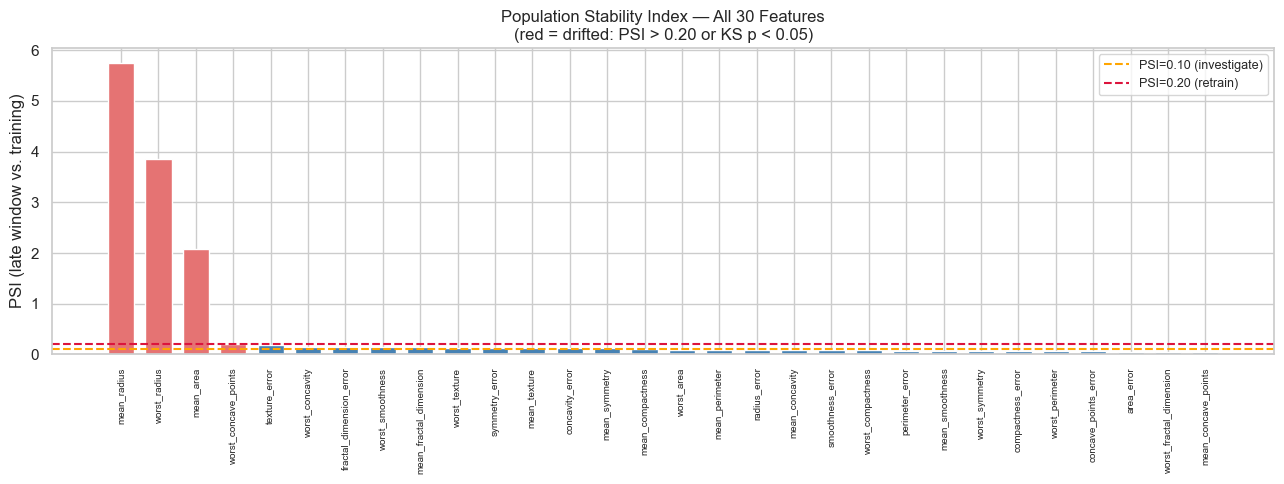

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(drift_df))
colors = ['#E57373' if d else 'steelblue' for d in drift_df['drifted']]
ax.bar(x, drift_df['psi_late'], color=colors, edgecolor='white', width=0.7)
ax.axhline(0.1, color='orange', lw=1.5, linestyle='--', label='PSI=0.10 (investigate)')
ax.axhline(0.2, color='crimson', lw=1.5, linestyle='--', label='PSI=0.20 (retrain)')
ax.set_xticks(x)
ax.set_xticklabels(drift_df['feature'], rotation=90, fontsize=7)
ax.set_ylabel('PSI (late window vs. training)')
ax.set_title('Population Stability Index — All 30 Features\n'
             '(red = drifted: PSI > 0.20 or KS p < 0.05)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_psi_all_features.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Distribution Shift — Top Drifted vs. Stable

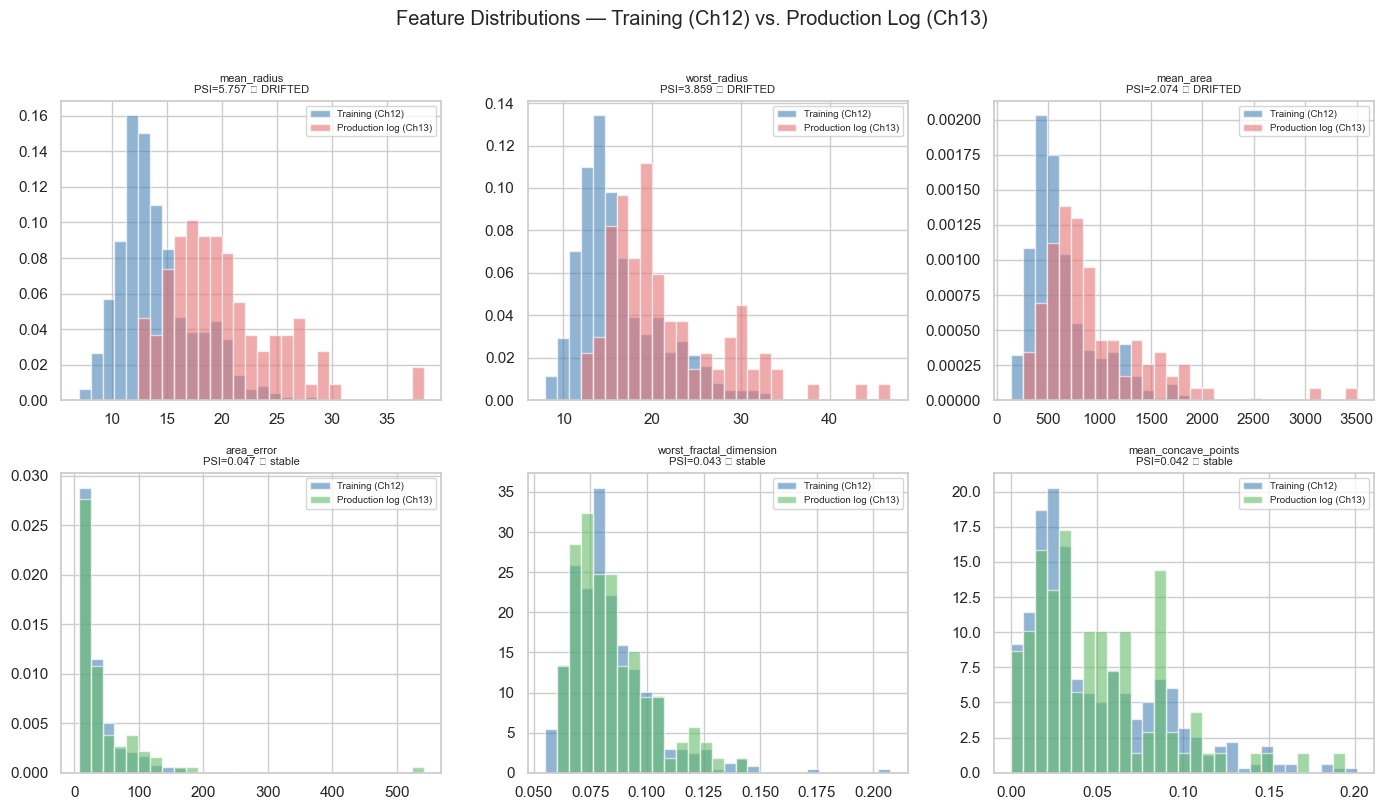

In [7]:
top_drift = drift_df[drift_df['drifted']].head(3)['feature'].tolist()
stable    = drift_df[~drift_df['drifted']].tail(3)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat, drifted in zip(axes.flatten(), top_drift + stable, [True]*3 + [False]*3):
    ref_vals  = ref_features[feat].values
    late_vals = prod_late[feat].values
    bins = np.linspace(min(ref_vals.min(), late_vals.min()),
                       max(ref_vals.max(), late_vals.max()), 30)
    ax.hist(ref_vals,  bins=bins, alpha=0.6, color='steelblue',
            density=True, label='Training (Ch12)')
    ax.hist(late_vals, bins=bins, alpha=0.6,
            color='#E57373' if drifted else '#66BB6A',
            density=True, label='Production log (Ch13)')
    psi_val = drift_df.loc[drift_df['feature'] == feat, 'psi_late'].values[0]
    flag = ' ⚠ DRIFTED' if drifted else ' ✓ stable'
    ax.set_title(f'{feat}\nPSI={psi_val:.3f}{flag}', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions — Training (Ch12) vs. Production Log (Ch13)', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Monitoring Model Performance Drift

True labels were written into the Chapter 13 log, so rolling accuracy and F1 can be computed directly from `log_df` without any additional labelling step.

In [8]:
WINDOW = 20
rolling_acc, rolling_f1, rolling_prob_mean, request_idx = [], [], [], []

for i in range(WINDOW, len(log_df) + 1):
    w        = log_df.iloc[i - WINDOW : i]
    y_true_w = w['true_label'].values
    y_pred_w = w['prediction'].values
    y_prob_w = w['probability'].values
    rolling_acc.append(accuracy_score(y_true_w, y_pred_w))
    rolling_f1.append(f1_score(y_true_w, y_pred_w, zero_division=0))
    rolling_prob_mean.append(y_prob_w.mean())
    request_idx.append(i)

pre_acc  = np.mean(rolling_acc[:80])
post_acc = np.mean(rolling_acc[-80:])
print(f'Mean rolling accuracy — pre-drift  : {pre_acc:.4f}')
print(f'Mean rolling accuracy — post-drift : {post_acc:.4f}')
print(f'Accuracy drop                       : {pre_acc - post_acc:.4f} '
      f'({(pre_acc - post_acc)/pre_acc*100:.1f}%)')


Mean rolling accuracy — pre-drift  : 0.9600
Mean rolling accuracy — post-drift : 0.9394
Accuracy drop                       : 0.0206 (2.1%)


### Visualising Rolling Performance Metrics

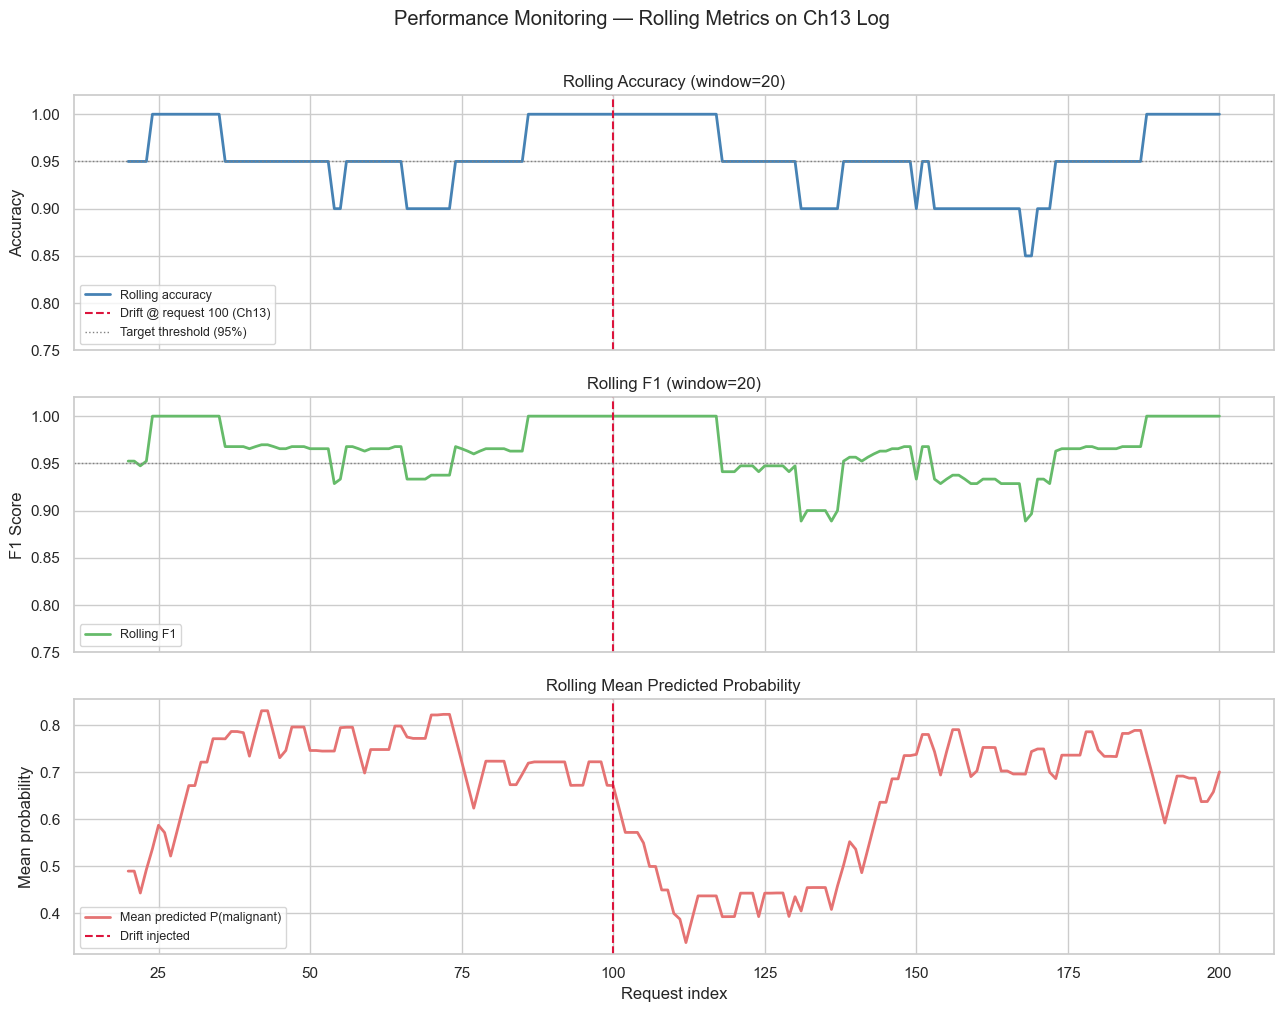

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
x = request_idx

axes[0].plot(x, rolling_acc, color='steelblue', lw=2, label='Rolling accuracy')
axes[0].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift @ request 100 (Ch13)')
axes[0].axhline(0.95, color='gray', lw=1, linestyle=':', label='Target threshold (95%)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Rolling Accuracy (window={WINDOW})')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.75, 1.02)

axes[1].plot(x, rolling_f1, color='#66BB6A', lw=2, label='Rolling F1')
axes[1].axvline(100, color='crimson', lw=1.5, linestyle='--')
axes[1].axhline(0.95, color='gray', lw=1, linestyle=':')
axes[1].set_ylabel('F1 Score')
axes[1].set_title(f'Rolling F1 (window={WINDOW})')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.75, 1.02)

axes[2].plot(x, rolling_prob_mean, color='#E57373', lw=2,
             label='Mean predicted P(malignant)')
axes[2].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift injected')
axes[2].set_ylabel('Mean probability')
axes[2].set_xlabel('Request index')
axes[2].set_title('Rolling Mean Predicted Probability')
axes[2].legend(fontsize=9)

plt.suptitle('Performance Monitoring — Rolling Metrics on Ch13 Log', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_perf_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()


## Drift Response Decision Framework

In [10]:
decision_rules = [
    ('PSI < 0.10 on all features',       'No labels available',   'No action',           'Continue monitoring'),
    ('0.10 ≤ PSI < 0.20 on some feats',  'No labels available',   'Investigate',         'Increase frequency; inspect flagged features'),
    ('PSI ≥ 0.20 on any feature',         'No labels available',   'Prepare retrain',     'Collect fresh labels; stage training run'),
    ('PSI ≥ 0.20 on any feature',         'Accuracy drop > 3%',    'Retrain immediately', 'Retrain on recent data; shadow-deploy candidate'),
    ('PSI < 0.10 on all features',        'Accuracy drop > 3%',    'Concept drift',       'Investigate label shift; check data quality'),
]

print(f'  {"Feature Drift":<38}  {"Label Status":<22}  {"Decision":<22}  Action')
print('  ' + '─' * 108)
for r in decision_rules:
    print(f'  {r[0]:<38}  {r[1]:<22}  {r[2]:<22}  {r[3]}')

# Apply to current experiment
acc_drop = (pre_acc - post_acc) / pre_acc * 100
max_psi  = drift_df['psi_late'].max()
print(f'\n── Applying to Ch13 log ───────────────────────────────────────────────')
print(f'  Features with PSI > 0.20 : {n_drifted}  (max PSI = {max_psi:.2f})')
print(f'  Rolling accuracy drop    : {acc_drop:.1f}%')

if n_drifted > 0 and acc_drop > 3.0:
    verdict = 'RETRAIN IMMEDIATELY'
elif n_drifted > 0:
    verdict = 'PREPARE RETRAINING'
elif acc_drop > 3.0:
    verdict = 'INVESTIGATE — possible concept drift'
else:
    verdict = 'NO ACTION'
print(f'\n  ► Verdict: {verdict}')


  Feature Drift                           Label Status            Decision                Action
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────
  PSI < 0.10 on all features              No labels available     No action               Continue monitoring
  0.10 ≤ PSI < 0.20 on some feats         No labels available     Investigate             Increase frequency; inspect flagged features
  PSI ≥ 0.20 on any feature               No labels available     Prepare retrain         Collect fresh labels; stage training run
  PSI ≥ 0.20 on any feature               Accuracy drop > 3%      Retrain immediately     Retrain on recent data; shadow-deploy candidate
  PSI < 0.10 on all features              Accuracy drop > 3%      Concept drift           Investigate label shift; check data quality

── Applying to Ch13 log ───────────────────────────────────────────────
  Features with PSI > 0.20 : 4  (max PSI = 5.76)
  Rolling accuracy dro

## Production Deployment Checklist

All 16 tasks across Chapters 12–14.

In [11]:
checklist = [
    ('Serialise',  'Save model + scaler + feature list (joblib bundle)',   '12'),
    ('Serialise',  'Include metadata (version, trained_at, AUC)',          '12'),
    ('Serialise',  'Verify reload — assert np.allclose(orig, loaded)',     '12'),
    ('Serialise',  'Register artifact with versioned dir + manifest.json', '12'),
    ('API',        'Define Pydantic input schema with ge=0 constraints',   '13'),
    ('API',        'Define Pydantic response schema with latency_ms',      '13'),
    ('API',        'Load model in lifespan context (once at startup)',      '13'),
    ('API',        'Expose /health liveness probe (200 or 503)',           '13'),
    ('API',        'Implement /predict endpoint',                          '13'),
    ('Logging',    'Log all requests with features + prediction (NDJSON)', '13'),
    ('Logging',    'Include request_id (uuid4) per request',              '13'),
    ('Logging',    'Include model_version in every log record',            '13'),
    ('Monitoring', 'Compute PSI per feature on rolling window',            '14'),
    ('Monitoring', 'Flag features with PSI > 0.20 or KS p < 0.05',        '14'),
    ('Monitoring', 'Track rolling accuracy/F1 when labels arrive',         '14'),
    ('Monitoring', 'Define retraining trigger conditions',                 '14'),
]
icons = {'Serialise': '🔵', 'API': '🟢', 'Logging': '🟡', 'Monitoring': '🟣'}
print(f'  {"Stage":<12}  {"Ch":>3}  Task')
print('  ' + '─' * 72)
for stage, task, ch in checklist:
    print(f'  {icons[stage]} {stage:<9}  {ch:>3}  {task}')
print(f'\n  {len(checklist)} tasks  ✓')


  Stage          Ch  Task
  ────────────────────────────────────────────────────────────────────────
  🔵 Serialise   12  Save model + scaler + feature list (joblib bundle)
  🔵 Serialise   12  Include metadata (version, trained_at, AUC)
  🔵 Serialise   12  Verify reload — assert np.allclose(orig, loaded)
  🔵 Serialise   12  Register artifact with versioned dir + manifest.json
  🟢 API         13  Define Pydantic input schema with ge=0 constraints
  🟢 API         13  Define Pydantic response schema with latency_ms
  🟢 API         13  Load model in lifespan context (once at startup)
  🟢 API         13  Expose /health liveness probe (200 or 503)
  🟢 API         13  Implement /predict endpoint
  🟡 Logging     13  Log all requests with features + prediction (NDJSON)
  🟡 Logging     13  Include request_id (uuid4) per request
  🟡 Logging     13  Include model_version in every log record
  🟣 Monitoring   14  Compute PSI per feature on rolling window
  🟣 Monitoring   14  Flag features with PSI > 